# Analyse de données multimodales d'athlètes

Trois participants suivis de novembre 2019 à mars 2020.
Sources : capteur Fitbit, questionnaires quotidiens, déclarations alimentaires.

Objectif : construire une table exploitable au pas journalier, puis modéliser
le risque de blessure et un indice de capacité à performer.

## Ce que contient le jeu de données

Des mesures objectives du capteur : activité, fréquence cardiaque, architecture
du sommeil, séances détectées.

Des mesures auto-déclarées : fatigue, humeur, qualité du sommeil, courbatures,
stress, et une question de disponibilité perçue (readiness). Ces dimensions
correspondent au questionnaire de monitoring de Hooper et Mackinnon (1995) [1].

Des déclarations ponctuelles : séances avec effort perçu, blessures, repas.

## Ce qu'il ne contient pas

Aucune mesure de performance sportive : ni temps, ni puissance, ni test physique.

Cette absence cadre la seconde cible. Un indice construit à partir de mesures
auto-déclarées ne peut pas mesurer la performance. Il mesure une disponibilité
perçue, que la littérature appelle readiness (Sansone et al., 2023) [2].

Je le développe donc comme un indicateur de readiness, proxy de la capacité à
performer.

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
base = Path("data")
PARTICIPANTS = ["p01", "p03", "p05"]

1) Premiere etape:

Le jeu de données couvre trois participants suivis du 1er novembre 2019 au
31 mars 2020, avec trois sources par participant : capteur porté, questionnaires
quotidiens et déclarations alimentaires.

Avant toute modélisation, je vérifie la faisabilité :

- la structure des fichiers et leur présence  par participant
- la couverture temporelle (périodes manquantes, granularité de chaque source)
- le nombre d'événements exploitables (durée, type de blessures)

Cette étape produit un état des lieux

1.1 Verifier la presence des fichier par participant

In [45]:
# 1.0 — Presence des fichiers par participant

for pid in PARTICIPANTS:
    fichiers = sorted(f.name for f in (base / pid / "fitbit").glob("*")
                      if not f.name.startswith("."))
    print(f"{pid} : {fichiers}")


p01 : ['calories.json', 'distance.json', 'exercise.json', 'heart_rate.json', 'resting_heart_rate.json', 'sleep.json', 'sleep_score.csv', 'steps.json', 'time_in_heart_rate_zones.json']
p03 : ['calories.json', 'distance.json', 'exercise.json', 'resting_heart_rate.json', 'sleep.json', 'sleep_score.csv', 'steps.json', 'time_in_heart_rate_zones.json']
p05 : ['calories.json', 'distance.json', 'exercise.json', 'heart_rate.json', 'resting_heart_rate.json', 'sleep.json', 'sleep_score.csv', 'steps.json', 'time_in_heart_rate_zones.json']


1.3 — Couverture temporelle et volumétrie

In [48]:


resume = []

for pid in PARTICIPANTS:
    with open(base / pid / "fitbit" / "steps.json", encoding="utf-8") as fh:
        steps = json.load(fh)
    dates = pd.to_datetime(pd.DataFrame(steps)["dateTime"]).dt.normalize()

    wellness = pd.read_csv(base / pid / "pmsys" / "wellness.csv")
    srpe = pd.read_csv(base / pid / "pmsys" / "srpe.csv")
    injury = pd.read_csv(base / pid / "pmsys" / "injury.csv")
    injury["positive"] = injury["injuries"] != "{}"

    resume.append({
        "participant": pid,
        "debut": dates.min().date(),
        "fin": dates.max().date(),
        "jours_fitbit": dates.nunique(),
        "n_wellness": len(wellness),
        "n_seances": len(srpe),
        "n_decl_blessure": len(injury),
        "n_blessures_pos": injury["positive"].sum(),
    })

audit = pd.DataFrame(resume)
audit

,participant,debut,fin,jours_fitbit,n_wellness,n_seances,n_decl_blessure,n_blessures_pos
0,p01,2019-11-01,2020-03-31,152,138,34,24,1
1,p03,2019-11-01,2020-03-31,122,82,2,11,0
2,p05,2019-11-01,2020-03-31,144,137,9,10,10


 1.2 Structure des sources

In [54]:
for pid in PARTICIPANTS:
    print(f"\n{'='*70}\n{pid}\n{'='*70}")

    for f in sorted((base / pid / "fitbit").glob("*.json")):
        with open(f, encoding="utf-8") as fh:
            contenu = json.load(fh)
        exemple = contenu[0] if isinstance(contenu, list) and contenu else None
        cles = list(exemple.keys()) if isinstance(exemple, dict) else "-"
        print(f"  {f.name:32s} n={len(contenu):>9,}  cles={cles}")

    for dossier, motif in [("pmsys", "*.csv"), ("googledocs", "*.csv")]:
        for f in sorted((base / pid / dossier).glob(motif)):
            t = pd.read_csv(f)
            print(f"  {f.name:32s} n={len(t):>9,}  cles={t.columns.tolist()}")


p01
  calories.json                    n=  218,880  cles=['dateTime', 'value']
  distance.json                    n=  218,836  cles=['dateTime', 'value']
  exercise.json                    n=      190  cles=['logId', 'activityName', 'activityTypeId', 'activityLevel', 'averageHeartRate', 'calories', 'duration', 'activeDuration', 'steps', 'logType', 'manualValuesSpecified', 'heartRateZones', 'lastModified', 'startTime', 'originalStartTime', 'originalDuration', 'elevationGain', 'hasGps', 'shouldFetchDetails']
  heart_rate.json                  n=1,573,165  cles=['dateTime', 'value']
  resting_heart_rate.json          n=      152  cles=['dateTime', 'value']
  sleep.json                       n=      155  cles=['logId', 'dateOfSleep', 'startTime', 'endTime', 'duration', 'minutesToFallAsleep', 'minutesAsleep', 'minutesAwake', 'minutesAfterWakeup', 'timeInBed', 'efficiency', 'type', 'infoCode', 'levels', 'mainSleep']
  steps.json                       n=  218,836  cles=['dateTime', 'value']


Jours manquants selon la periode attendue

In [51]:
periode_attendue = pd.date_range("2019-11-01", "2020-03-31", freq="D")

for pid in PARTICIPANTS:
    with open(base / pid / "fitbit" / "steps.json", encoding="utf-8") as fh:
        d = json.load(fh)
    dates = pd.to_datetime(pd.DataFrame(d)["dateTime"]).dt.normalize().unique()
    manquants = periode_attendue.difference(pd.DatetimeIndex(dates))

    print(f"\n{pid} : {len(manquants)} jours manquants")
    if len(manquants):
        print(manquants.strftime("%Y-%m-%d").tolist())


p01 : 0 jours manquants

p03 : 30 jours manquants
['2019-11-04', '2019-11-10', '2019-11-17', '2019-11-18', '2019-11-19', '2019-11-20', '2019-11-21', '2019-11-22', '2019-11-23', '2019-11-24', '2019-11-25', '2019-11-26', '2019-11-27', '2019-11-28', '2019-11-29', '2019-11-30', '2019-12-01', '2019-12-02', '2019-12-03', '2019-12-04', '2019-12-05', '2019-12-06', '2019-12-07', '2019-12-08', '2019-12-09', '2020-02-29', '2020-03-01', '2020-03-02', '2020-03-03', '2020-03-28']

p05 : 8 jours manquants
['2019-11-11', '2020-02-08', '2020-02-22', '2020-02-23', '2020-02-24', '2020-02-25', '2020-02-26', '2020-02-27']


 Structure temporelle des declarations de blessure


In [58]:
for pid in PARTICIPANTS:
    inj = pd.read_csv(base / pid / "pmsys" / "injury.csv")
    inj["date"] = pd.to_datetime(inj["effective_time_frame"]).dt.normalize()
    inj["positive"] = inj["injuries"] != "{}"
    inj["ecart_jours"] = inj["date"].diff().dt.days

    print(f"\n{pid} — {inj['positive'].sum()} positives sur {len(inj)} declarations")
    print(inj[["date", "injuries", "ecart_jours"]].to_string(index=False))

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 7)

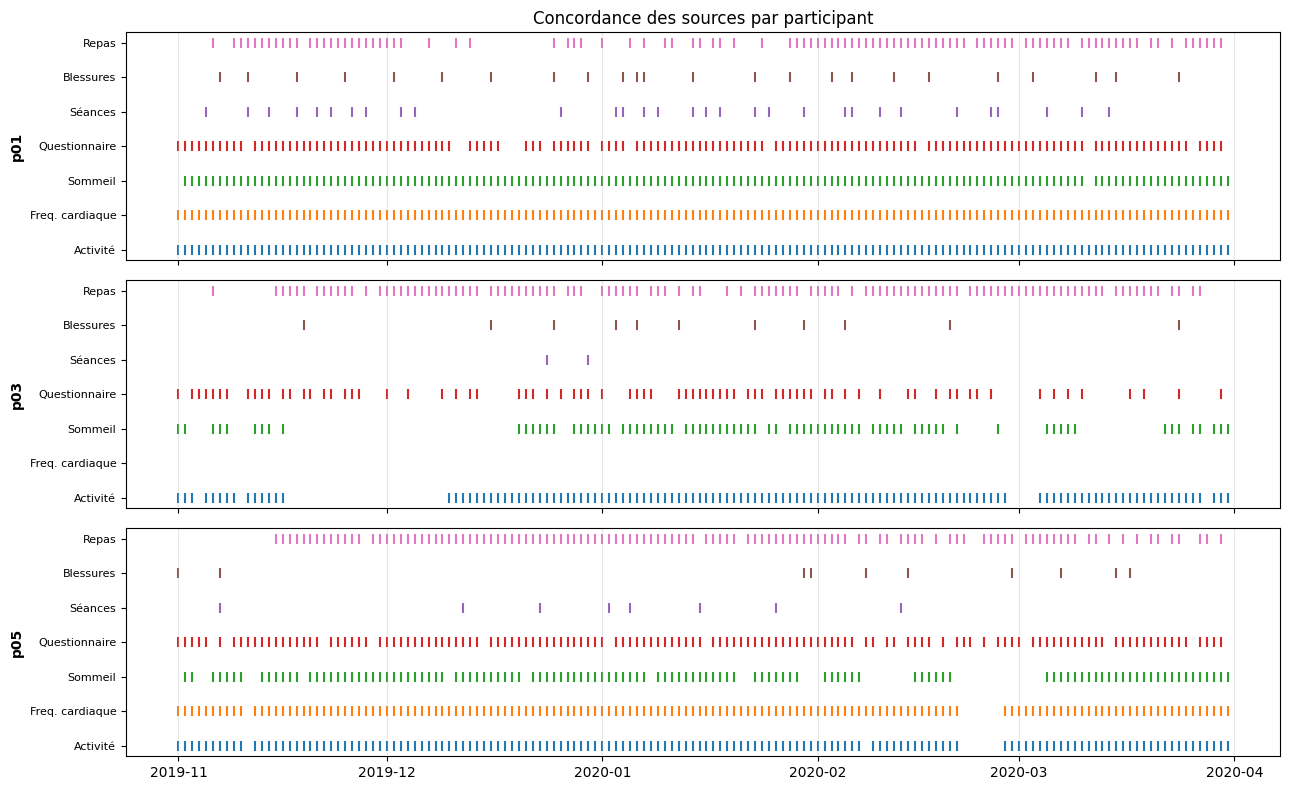

In [60]:
sources = {
    "Activité": lambda pid: _dates_json(pid, "fitbit/steps.json"),
    "Freq. cardiaque": lambda pid: _dates_json(pid, "fitbit/heart_rate.json"),
    "Sommeil": lambda pid: _dates_sommeil(pid),
    "Questionnaire": lambda pid: _dates_csv(pid, "pmsys/wellness.csv", "effective_time_frame"),
    "Séances": lambda pid: _dates_csv(pid, "pmsys/srpe.csv", "end_date_time"),
    "Blessures": lambda pid: _dates_csv(pid, "pmsys/injury.csv", "effective_time_frame"),
    "Repas": lambda pid: _dates_csv(pid, "googledocs/reporting.csv", "date", dayfirst=True),
}

def _dates_json(pid, rel):
    f = base / pid / rel
    if not f.exists():
        return pd.DatetimeIndex([])
    with open(f, encoding="utf-8") as fh:
        d = json.load(fh)
    return pd.DatetimeIndex(pd.to_datetime(pd.DataFrame(d)["dateTime"]).dt.normalize().unique())

def _dates_sommeil(pid):
    with open(base / pid / "fitbit" / "sleep.json", encoding="utf-8") as fh:
        d = json.load(fh)
    return pd.DatetimeIndex(pd.to_datetime(pd.DataFrame(d)["dateOfSleep"]).unique())

def _dates_csv(pid, rel, col, dayfirst=False):
    f = base / pid / rel
    if not f.exists():
        return pd.DatetimeIndex([])
    t = pd.read_csv(f)
    dt = pd.to_datetime(t[col], utc=True, dayfirst=dayfirst).dt.tz_localize(None).dt.normalize()
    return pd.DatetimeIndex(dt.unique())

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

for ax, pid in zip(axes, PARTICIPANTS):
    for j, (nom, f) in enumerate(sources.items()):
        dates = f(pid)
        ax.scatter(dates, [j] * len(dates), marker="|", s=60)
    ax.set_yticks(range(len(sources)))
    ax.set_yticklabels(sources.keys(), fontsize=8)
    ax.set_ylabel(pid, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

axes[0].set_title("Concordance des sources par participant")
plt.tight_layout()
plt.show()

### Constats de l'audit

**Couverture temporelle.** Les 3 participants couvrent la même période
(1er novembre 2019 - 31 mars 2020) mais avec des disponibilités différentes :
152 jours de données Fitbit pour p01, 144 pour p05, 122 pour p03. Les manquants
forment des blocs — 23 jours consécutifs chez p03 en novembre-décembre, 6 chez
p05 fin février — et non des trous dispersés. Cela oriente vers des périodes
sans port du bracelet. p03 ne dispose par ailleurs d'aucun fichier de fréquence
cardiaque.

**Valeurs générées par Fitbit.** Le fichier calories.json compte exactement
218 880 lignes pour les trois participants, soit 152 jours × 1440 minutes.
Fitbit produit une valeur à chaque minute indépendamment du port effectif, alors
que les fichiers de pas varient de 53 042 à 218 836 lignes. La complétude
apparente des calories est donc trompeuse.

**Charge d'entraînement.** Le sRPE est très inégalement renseigné : 34 séances
pour p01, 9 pour p05, 2 pour p03. Cette source ne permet pas de construire un
indicateur comparable entre participants. Les données d'activité Fitbit seront
privilégiées.

**Déclarations de blessure.** Sur 45 déclarations, 11 sont positives : 1 chez p01
sur 24, 0 chez p03 sur 11, 10 chez p05 sur 10. p01 renseigne le formulaire
régulièrement, qu'il soit blessé ou non ; p05 ne le renseigne qu'en cas de
blessure. Les trois ne mesurent donc pas le même phénomène.

Les huit déclarations de p05 au pied gauche s'échelonnent du 30 janvier au
17 mars, avec des écarts de 1 à 15 jours, après 84 jours sans déclaration. Cette
structure correspond à un épisode persistant redéclaré plutôt qu'à huit
blessures distinctes.

Après regroupement des déclarations consécutives sur une même zone, le nombre
d'épisodes distincts tombe à quatre : deux gênes isolées chez p05 en novembre
(pied gauche, cou), un épisode prolongé au pied gauche de janvier à mars, et une
atteinte à la main droite chez p01. Aucun ne semble présenter les caractéristiques d'une
lésion de surcharge.

## Deuxième étape : Agrégation au pas journalier

Les sources présentent des granularités hétérogènes : la minute pour les flux
d'activité, l'événement pour les séances et les nuits, la journée pour les
questionnaires. L'unité d'analyse retenue est le couple participant-jour.

Chaque source est donc agrégée à ce pas avant fusion, ce qui suppose de choisir
une statistique de résumé adaptée à chaque variable.

La fusion s'appuie sur une grille complète de 152 jours par participant plutôt
que sur les dates présentes dans les fichiers : les jours sans données
apparaissent ainsi en valeurs manquantes au lieu de disparaître.

In [61]:
def charger_flux_minute(chemin, nom, agg="sum"):
    """Agrège un flux Fitbit à la minute vers un pas journalier."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)
    df["date"] = pd.to_datetime(df["dateTime"]).dt.normalize()
    df["value"] = pd.to_numeric(df["value"])
    return df.groupby("date")["value"].agg(agg).rename(nom)

p = base / "p01" / "fitbit"
steps = charger_flux_minute(p / "steps.json", "steps")
calories = charger_flux_minute(p / "calories.json", "calories")
distance = charger_flux_minute(p / "distance.json", "distance_cm")

pd.concat([steps, calories, distance], axis=1).head()

def charger_heart_rate(chemin):
    """Agrège la frequence cardiaque minute vers des statistiques journalieres."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)
    df["date"] = pd.to_datetime(df["dateTime"]).dt.normalize()
    df["bpm"] = df["value"].apply(lambda v: v["bpm"])
    df["confiance"] = df["value"].apply(lambda v: v["confidence"])

    agg = df.groupby("date").agg(
        hr_mean=("bpm", "mean"),
        hr_min=("bpm", "min"),
        hr_max=("bpm", "max"),
        hr_std=("bpm", "std"),
        hr_n_mesures=("bpm", "size"),
        hr_confiance=("confiance", "mean"),
    )
    return agg

def charger_sommeil(chemin):
    """Extrait le resume des nuits de sommeil."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)

    df["date_reveil"] = pd.to_datetime(df["dateOfSleep"])
    df["date"] = df["date_reveil"] - pd.Timedelta(days=1)

    def phase(v, nom):
        return v.get("summary", {}).get(nom, {}).get("minutes")

    df["sommeil_profond"] = df["levels"].apply(lambda v: phase(v, "deep"))
    df["sommeil_rem"] = df["levels"].apply(lambda v: phase(v, "rem"))
    df["sommeil_leger"] = df["levels"].apply(lambda v: phase(v, "light"))

    df = df[df["mainSleep"]]

    agg = df.groupby("date").agg(
        sommeil_min=("minutesAsleep", "sum"),
        sommeil_efficacite=("efficiency", "mean"),
        sommeil_profond=("sommeil_profond", "sum"),
        sommeil_rem=("sommeil_rem", "sum"),
        temps_au_lit=("timeInBed", "sum"),
        minutes_eveille=("minutesAwake", "sum"),
    )
    return agg


def charger_exercices(chemin):
    """Agrege les seances detectees par Fitbit au pas journalier."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)

    df["date"] = pd.to_datetime(df["startTime"]).dt.normalize()
    df["duree_min"] = df["activeDuration"] / 60000

    agg = df.groupby("date").agg(
        ex_n_seances=("logId", "count"),
        ex_duree_min=("duree_min", "sum"),
        ex_calories=("calories", "sum"),
        ex_hr_moy=("averageHeartRate", "mean"),
    )
    return agg

def charger_zones_cardiaques(chemin):
    """Extrait les minutes passees dans chaque zone d'intensite."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)
    df["date"] = pd.to_datetime(df["dateTime"]).dt.normalize()

    zones = df["value"].apply(lambda v: v["valuesInZones"]).apply(pd.Series)
    zones.columns = [c.lower() for c in zones.columns]
    zones["date"] = df["date"].values

    return zones.groupby("date").sum()

def charger_wellness(chemin):
    """Charge le questionnaire quotidien."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["effective_time_frame"], utc=True).dt.normalize().dt.tz_localize(None)
    df["soreness_n_zones"] = df["soreness_area"].apply(lambda x: len(eval(x)) if pd.notna(x) else 0)
    cols = ["fatigue", "mood", "readiness", "sleep_duration_h",
            "sleep_quality", "soreness", "stress", "soreness_n_zones"]
    return df.groupby("date")[cols].mean()

def charger_srpe(chemin):
    """Calcule la charge d'entrainement declaree."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["end_date_time"], utc=True).dt.normalize().dt.tz_localize(None)
    df["srpe"] = df["perceived_exertion"] * df["duration_min"]
    return df.groupby("date").agg(
        srpe_total=("srpe", "sum"),
        srpe_n_seances=("srpe", "count"),
        srpe_duree=("duration_min", "sum"),
    )

def charger_wellness(chemin):
    """Charge le questionnaire quotidien."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["effective_time_frame"], utc=True).dt.normalize().dt.tz_localize(None)
    df["soreness_n_zones"] = df["soreness_area"].apply(lambda x: len(eval(x)) if pd.notna(x) else 0)
    cols = ["fatigue", "mood", "readiness", "sleep_duration_h",
            "sleep_quality", "soreness", "stress", "soreness_n_zones"]
    return df.groupby("date")[cols].mean()


def charger_blessures(chemin):
    """Extrait les declarations de blessure positives."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["effective_time_frame"], utc=True).dt.normalize().dt.tz_localize(None)
    df["blessure_declaree"] = (df["injuries"] != "{}").astype(int)
    return df.groupby("date")[["blessure_declaree"]].max()

def charger_si_existe(fonction, chemin, *args, **kwargs):
    """Retourne le resultat de la fonction, ou None si le fichier est absent."""
    if not Path(chemin).exists():
        print(f"  absent : {chemin.name}")
        return None
    return fonction(chemin, *args, **kwargs)

def charger_reporting(chemin):
    """Extrait la structure des prises alimentaires declarees."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["date"])

    for repas in ["Breakfast", "Lunch", "Dinner", "Evening"]:
        df[f"repas_{repas.lower()}"] = df["meals"].fillna("").str.contains(repas).astype(int)

    df["n_repas"] = df[[f"repas_{r}" for r in
                        ["breakfast", "lunch", "dinner", "evening"]]].sum(axis=1)

    cols = ["n_repas", "repas_breakfast", "repas_lunch", "repas_dinner",
            "repas_evening", "weight", "glasses_of_fluid", "alcohol_consumed"]
    return df.groupby("date")[cols].mean()

In [62]:
def construire_table_participant(pid):
    """Assemble toutes les sources d'un participant au pas journalier."""
    f = base / pid / "fitbit"
    pm = base / pid / "pmsys"

    sources = [
        charger_si_existe(charger_flux_minute, f / "steps.json", "steps"),
        charger_si_existe(charger_flux_minute, f / "calories.json", "calories"),
        charger_si_existe(charger_flux_minute, f / "distance.json", "distance_cm"),
        charger_si_existe(charger_heart_rate, f / "heart_rate.json"),
        charger_si_existe(charger_sommeil, f / "sleep.json"),
        charger_si_existe(charger_exercices, f / "exercise.json"),
        charger_si_existe(charger_wellness, pm / "wellness.csv"),
        charger_si_existe(charger_srpe, pm / "srpe.csv"),
        charger_si_existe(charger_blessures, pm / "injury.csv"),
        charger_si_existe(charger_reporting, base / pid / "googledocs" / "reporting.csv"),
        charger_photos(base / pid / "food-images"),
    ]
    sources = [s for s in sources if s is not None]

    grille = pd.DataFrame(
        index=pd.date_range("2019-11-01", "2020-03-31", freq="D", name="date")
    )

    for s in sources:
        grille = grille.join(s, how="left")

    grille["participant"] = pid
    return grille.reset_index()

def charger_reporting(chemin):
    """Extrait la structure des prises alimentaires declarees."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    for repas in ["Breakfast", "Lunch", "Dinner", "Evening"]:
        df[f"repas_{repas.lower()}"] = df["meals"].fillna("").str.contains(repas).astype(int)

    df["n_repas"] = df[[f"repas_{r}" for r in
                        ["breakfast", "lunch", "dinner", "evening"]]].sum(axis=1)

    df["alcool"] = (df["alcohol_consumed"].astype(str).str.lower()
                      .isin(["true", "yes", "1"]).astype(int))

    cols = ["n_repas", "repas_breakfast", "repas_lunch", "repas_dinner",
            "repas_evening", "weight", "glasses_of_fluid", "alcool"]
    return df.groupby("date")[cols].mean()

def charger_photos(dossier):
    """Extrait les prises alimentaires photographiees depuis les metadonnees EXIF."""
    if not Path(dossier).exists():
        return None

    lignes = []
    for f in Path(dossier).iterdir():
        if not f.is_file():
            continue
        d = lire_date_image(f)
        if d is not None:
            lignes.append({"horodatage": d})

    if not lignes:
        return None

    photos = pd.DataFrame(lignes)
    photos["date"] = photos["horodatage"].dt.normalize()

    agg = photos.groupby("date").agg(
        n_photos=("horodatage", "count"),
        premiere_prise=("horodatage", "min"),
        derniere_prise=("horodatage", "max"),
    )
    agg["fenetre_alim_h"] = (
        (agg["derniere_prise"] - agg["premiere_prise"]).dt.total_seconds() / 3600
    )
    agg["heure_premiere"] = agg["premiere_prise"].dt.hour
    agg["heure_derniere"] = agg["derniere_prise"].dt.hour

    return agg[["n_photos", "fenetre_alim_h", "heure_premiere", "heure_derniere"]]

from PIL import Image
from PIL.ExifTags import TAGS

def lire_date_image(chemin):
    """Retourne la date de prise de vue depuis les metadonnees EXIF."""
    try:
        img = Image.open(chemin)
        exif = img._getexif()
        if not exif:
            return None
        for tag_id, valeur in exif.items():
            if TAGS.get(tag_id) == "DateTimeOriginal":
                return pd.to_datetime(valeur, format="%Y:%m:%d %H:%M:%S")
    except Exception:
        return None
    return None

def nettoyer(df):
    """Corrections appliquees apres la fusion des sources."""
    df = df.sort_values(["participant", "date"]).copy()

    # jours sans port du bracelet : les calories generees par Fitbit
    # ne mesurent rien, seule la presence de pas atteste du port
    non_port = df["steps"].isna() | (df["steps"] == 0)
    cols_fitbit = ["steps", "calories", "distance_cm",
                   "hr_mean", "hr_min", "hr_max", "hr_std"]
    df.loc[non_port, [c for c in cols_fitbit if c in df.columns]] = np.nan
    df["fitbit_porte"] = (~non_port).astype(int)

    # etat de blessure propage sur 14 jours
    df["blessure_etat"] = df.groupby("participant")["blessure_declaree"].ffill(limit=14)

    return df


tables = [construire_table_participant(pid) for pid in PARTICIPANTS]
df = pd.concat(tables, ignore_index=True)
df = nettoyer(df)

print(df.shape)
print(df["participant"].value_counts())

In [67]:

tables = [construire_table_participant(pid) for pid in PARTICIPANTS]
df = pd.concat(tables, ignore_index=True)
def nettoyer(df):
    """Corrections appliquees apres la fusion des sources."""
    df = df.sort_values(["participant", "date"]).copy()

    # jours sans port du bracelet : les calories generees par Fitbit
    # ne mesurent rien, seule la presence de pas atteste du port
    non_port = df["steps"].isna() | (df["steps"] == 0)
    cols_fitbit = ["steps", "calories", "distance_cm",
                   "hr_mean", "hr_min", "hr_max", "hr_std"]
    df.loc[non_port, [c for c in cols_fitbit if c in df.columns]] = np.nan
    df["fitbit_porte"] = (~non_port).astype(int)

    # etat de blessure propage sur 14 jours
    df["blessure_etat"] = df.groupby("participant")["blessure_declaree"].ffill(limit=14)

    return df


df = nettoyer(df)
print(df.shape)
df.to_csv("test_dataset.csv", index=False)
print(df.shape)
df.head(10)


  absent : heart_rate.json
(456, 47)
(456, 47)


,date,steps,calories,distance_cm,hr_mean,hr_min,hr_max,hr_std,hr_n_mesures,hr_confiance,...,weight,glasses_of_fluid,alcool,n_photos,fenetre_alim_h,heure_premiere,heure_derniere,participant,fitbit_porte,blessure_etat
0,2019-11-01,17873.0,4009.10,1442400.0,66.140075,46.0,140.0,15.080539,10680.0,2.107491,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p01,1,NaN
1,2019-11-02,13118.0,3533.56,1058480.0,62.602226,44.0,122.0,15.280065,10154.0,2.188793,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p01,1,NaN
2,2019-11-03,14312.0,3748.73,1146085.0,64.551841,45.0,132.0,14.532847,10050.0,2.119502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p01,1,NaN
3,2019-11-04,10970.0,3353.38,885970.0,63.552109,44.0,126.0,13.494872,10315.0,2.081532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p01,1,NaN
4,2019-11-05,16186.0,3794.63,1371470.0,66.672530,44.0,163.0,23.635823,10972.0,2.110736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p01,1,NaN
5,2019-11-06,8189.0,3192.41,652160.0,63.886481,46.0,125.0,10.683099,10800.0,2.244815,...,100.0,7.0,0.0,NaN,NaN,NaN,NaN,p01,1,NaN
6,2019-11-07,8710.0,3143.87,704820.0,63.987872,46.0,143.0,12.153097,10389.0,2.223891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p01,1,0.0
7,2019-11-08,12888.0,3640.23,1036901.0,66.131098,47.0,129.0,14.563223,9901.0,2.142713,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p01,1,0.0
8,2019-11-09,16450.0,3912.61,1328711.0,64.781921,46.0,117.0,14.570858,10808.0,2.135640,...,100.0,6.0,0.0,NaN,NaN,NaN,NaN,p01,1,0.0
9,2019-11-10,17843.0,4014.13,1436660.0,64.822397,45.0,140.0,17.054088,10653.0,2.165399,...,100.0,9.0,0.0,NaN,NaN,NaN,NaN,p01,1,0.0


### 3.1 Complétude par variable et par participant

La proportion de valeurs renseignées conditionne l'exploitabilité de chaque
variable. Elle est mesurée par participant, les écarts entre sujets étant
potentiellement plus informatifs que le taux global.

In [9]:
completude = df.groupby("participant").apply(
    lambda g: g.notna().mean() * 100
).round(1).T

completude

p03 = df[df["participant"] == "p03"]
print(p03.loc[p03["steps"].isna(), "calories"].describe())
print(p03.loc[p03["steps"].notna(), "calories"].describe())
df.loc[df["steps"].isna(), "calories"] = np.nan

count      30.000000
mean     1940.160000
std         6.476781
min      1929.600000
25%      1933.200000
50%      1944.000000
75%      1944.000000
max      1944.000000
Name: calories, dtype: float64
count     122.000000
mean     2653.453033
std       549.611159
min      1929.600000
25%      2144.272500
50%      2679.685000
75%      2944.555000
max      4793.300000
Name: calories, dtype: float64


### Constats

Trois profils de couverture se dégagent. p01 est renseigné de façon homogène,
p05 présente un déficit sur le sommeil, p03 est en retrait sur l'ensemble des
sources déclaratives.

Deux limitations structurelles apparaissent. Le sRPE, source théoriquement
privilégiée pour la charge d'entraînement, n'est renseigné que sur 20 %, 5 % et
1 % des jours selon le participant : il ne permet pas de construire un
indicateur comparable. Et p03 ne dispose d'aucun fichier de fréquence cardiaque
minute, ce qui exclut pour lui six variables.

Enfin, la complétude apparente de 100 % sur les calories est trompeuse. Sur les
trente jours où p03 n'a pas de données de pas, les calories affichent une
moyenne de 1 940 pour un écart-type de 6,5, contre 2 653 et 550 sur les jours
renseignés. Fitbit impute manifestement un métabolisme de base en l'absence de
port du bracelet. Ces valeurs sont donc ramenées à l'état manquant, la présence
de pas servant de critère de port effectif.

In [10]:
variables = ["steps", "calories", "distance_cm", "hr_mean", "hr_min", "hr_max",
             "sommeil_min", "sommeil_efficacite", "fatigue", "readiness",
             "soreness", "stress"]

df[variables].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
steps,418.0,10077.8,5085.1,0.0,7147.8,10405.5,13273.8,24846.0
calories,418.0,3280.4,649.1,1929.6,2881.2,3357.7,3729.7,5225.8
distance_cm,418.0,784090.4,403338.2,0.0,558283.8,815310.5,1022747.5,2058360.0
hr_mean,297.0,69.3,6.7,56.5,63.5,69.5,74.5,90.0
hr_min,297.0,45.9,4.1,30.0,44.0,46.0,48.0,68.0
hr_max,297.0,137.0,17.8,95.0,124.0,132.0,146.0,200.0
sommeil_min,345.0,374.6,92.3,58.0,329.0,364.0,403.0,864.0
sommeil_efficacite,345.0,95.8,2.6,85.0,94.0,96.0,98.0,100.0
fatigue,350.0,2.7,0.5,1.0,2.0,3.0,3.0,4.0
readiness,350.0,4.6,2.3,0.0,5.0,5.0,6.0,8.0


In [11]:
echelles = ["fatigue", "mood", "sleep_quality", "soreness", "stress"]
df = df[~(df[echelles] == 0).all(axis=1)]
non_port = df["steps"].isna() | (df["steps"] == 0)
cols_fitbit = ["steps", "calories", "distance_cm",
               "hr_mean", "hr_min", "hr_max", "hr_std"]
df.loc[non_port, cols_fitbit] = np.nan

non_port = df["steps"].isna() | (df["steps"] == 0)
cols_fitbit = ["steps", "calories", "distance_cm",
               "hr_mean", "hr_min", "hr_max", "hr_std"]
df.loc[non_port, cols_fitbit] = np.nan

df["fitbit_porte"] = (~non_port).astype(int)

print(df.loc[df["sommeil_min"] > 700, "date"].dt.day_name())

longues = df["sommeil_min"] > 700
print(df.loc[longues, ["date", "participant", "sommeil_min", "temps_au_lit",
                       "sommeil_efficacite", "steps", "readiness"]])

35        Friday
125     Thursday
164    Wednesday
224       Sunday
310     Thursday
370       Monday
Name: date, dtype: object
          date participant  sommeil_min  temps_au_lit  sommeil_efficacite  \
35  2019-12-06         p01        848.0         944.0                94.0   
125 2020-03-05         p01        738.0         838.0                94.0   
164 2019-11-13         p03        864.0         962.0                96.0   
224 2020-01-12         p03        776.0         874.0                97.0   
310 2019-11-07         p05        730.0         842.0                93.0   
370 2020-01-06         p05        714.0         806.0                92.0   

       steps  readiness  
35   10401.0        3.0  
125  20119.0        8.0  
164     13.0        5.0  
224   7019.0        5.0  
310  19247.0        0.0  
370  23971.0        5.0  


### Non-modélisabilité de la cible « blessure »

Après propagation de l'état déclaré sur une fenêtre de 14 jours, la variable
présente une distribution dégénérée : p05 est en état de blessure sur 100 % des
83 jours renseignés, p03 sur 0 % de ses 104 jours, et seul p01 présente une
variation avec 7 jours sur 146.

La variance de la cible est donc portée par l'identité du participant et non par
un état physiologique variable dans le temps. Un modèle entraîné sur ces données
apprendrait à discriminer les sujets entre eux plutôt qu'à identifier des
conditions précédant une blessure.

Ce constat s'ajoute à trois limitations déjà établies lors de l'audit :

- le regroupement des déclarations consécutives sur une même zone anatomique
  ramène le nombre d'épisodes distincts à quatre pour l'ensemble des trois
  participants ;
- les localisations observées (main droite, cou, pied gauche) et le caractère
  mineur des atteintes n'orientent pas vers des lésions de surcharge, seul
  mécanisme que les variables de charge disponibles permettraient d'approcher ;
- les taux de déclaration hétérogènes entre participants traduisent des usages
  différents du questionnaire et non des risques différents.

La prédiction du risque de blessure est donc traitée dans la suite comme une
démonstration de démarche. Le pipeline complet est construit et un modèle est
entraîné, mais les métriques obtenues ne sont pas interprétables et ne sont
présentées qu'à ce titre.

In [12]:
img_dir = base / "p01" / "food-images"
print("dossier existe :", img_dir.exists())

if img_dir.exists():
    fichiers = [f for f in img_dir.iterdir() if f.is_file()]
    print(len(fichiers), "fichiers")
    print([f.name for f in fichiers[:5]])

dossier existe : True
321 fichiers
['IMG_8916.jpeg', 'IMG_8917.jpeg', 'IMG_8918.jpeg', 'IMG_8920.jpeg', 'IMG_8921.jpeg']


### Estimation calorique à partir des images

Cette approche est écartée pour trois raisons.

Les pipelines d'estimation calorique reposent sur un objet de calibration dans le
champ — souvent le pouce placé près du plat — pour convertir surface en volume.
Les photographies disponibles n'en comportent aucun.

Une étude de crowdsourcing (JMIR, 2018, n=2028) rapporte une précision moyenne de
5 bonnes réponses sur 20, à 20 % près de la valeur réelle. Cinq experts en
nutrition obtiennent le même score.

Enfin, aucune vérité terrain calorique n'accompagne les images : l'erreur d'une
estimation serait invérifiable.

Les images sont donc exploitées pour ce qu'elles mesurent de façon fiable : date
et heure EXIF, nombre de prises alimentaires par jour, amplitude de la fenêtre
alimentaire. Les apports déclarés dans reporting.csv servent de source
complémentaire.

In [13]:
rep = pd.read_csv(base / "p01" / "googledocs" / "reporting.csv")
print(rep.shape)
print(rep.columns.tolist())
rep.head(3)
lignes = []
for f in fichiers:
    d = lire_date_image(f)
    if d is not None:
        lignes.append({"fichier": f.name, "horodatage": d})

photos = pd.DataFrame(lignes)
photos["date"] = photos["horodatage"].dt.normalize()
print(len(photos), "dates extraites sur", len(fichiers))
photos.head()
print(rep["meals"].head(10).to_string())

(109, 6)
['date', 'timestamp', 'meals', 'weight', 'glasses_of_fluid', 'alcohol_consumed']
321 dates extraites sur 321
0                    Breakfast, Dinner
1                   Breakfast, Evening
2             Breakfast, Lunch, Dinner
3                    Breakfast, Dinner
4             Breakfast, Lunch, Dinner
5           Breakfast, Dinner, Evening
6    Breakfast, Lunch, Dinner, Evening
7             Breakfast, Lunch, Dinner
8             Breakfast, Lunch, Dinner
9                    Breakfast, Dinner


In [14]:
rep_brut = pd.read_csv(base / "p01" / "googledocs" / "reporting.csv")
print(rep_brut.dtypes)
print(rep_brut["alcohol_consumed"].unique())
print(rep_brut["weight"].unique()[:10])
print(rep_brut["glasses_of_fluid"].unique()[:10])
def charger_reporting(chemin):
    """Extrait la structure des prises alimentaires declarees."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    for repas in ["Breakfast", "Lunch", "Dinner", "Evening"]:
        df[f"repas_{repas.lower()}"] = df["meals"].fillna("").str.contains(repas).astype(int)

    df["n_repas"] = df[[f"repas_{r}" for r in
                        ["breakfast", "lunch", "dinner", "evening"]]].sum(axis=1)

    df["alcool"] = (df["alcohol_consumed"].astype(str).str.lower()
                      .isin(["true", "yes", "1"]).astype(int))

    cols = ["n_repas", "repas_breakfast", "repas_lunch", "repas_dinner",
            "repas_evening", "weight", "glasses_of_fluid", "alcool"]
    return df.groupby("date")[cols].mean()

date                 object
timestamp            object
meals                object
weight              float64
glasses_of_fluid      int64
alcohol_consumed     object
dtype: object
['No']
[100.  101.  102.   99.  100.5   nan]
[ 7  6  9  5  8 10 11 13]


In [15]:
tables = [construire_table_participant(pid) for pid in PARTICIPANTS]
df = pd.concat(tables, ignore_index=True)

print(df.shape)
print(df.columns.tolist())

  absent : heart_rate.json
(456, 45)
['date', 'steps', 'calories', 'distance_cm', 'hr_mean', 'hr_min', 'hr_max', 'hr_std', 'hr_n_mesures', 'hr_confiance', 'sommeil_min', 'sommeil_efficacite', 'sommeil_profond', 'sommeil_rem', 'temps_au_lit', 'minutes_eveille', 'ex_n_seances', 'ex_duree_min', 'ex_calories', 'ex_hr_moy', 'fatigue', 'mood', 'readiness', 'sleep_duration_h', 'sleep_quality', 'soreness', 'stress', 'soreness_n_zones', 'srpe_total', 'srpe_n_seances', 'srpe_duree', 'blessure_declaree', 'n_repas', 'repas_breakfast', 'repas_lunch', 'repas_dinner', 'repas_evening', 'weight', 'glasses_of_fluid', 'alcool', 'n_photos', 'fenetre_alim_h', 'heure_premiere', 'heure_derniere', 'participant']


In [16]:
        charger_si_existe(charger_reporting, base / pid / "googledocs" / "reporting.csv"),
        charger_photos(base / pid / "food-images"),

(            n_photos  fenetre_alim_h  heure_premiere  heure_derniere
 date                                                                
 2020-02-01        12       11.357500               6              18
 2020-02-02         1        0.000000               8               8
 2020-02-03         1        0.000000              12              12
 2020-02-04         3        1.390556               8               9
 2020-02-05         1        0.000000              10              10
 2020-02-06         5        5.746111               7              12
 2020-02-07         3        6.806944              10              17
 2020-02-08         1        0.000000               8               8
 2020-02-09         1        0.000000               9               9
 2020-02-10         2        0.001944              13              13
 2020-02-11        10        8.176667               9              17
 2020-02-12        13       15.465278               6              22
 2020-02-13         

In [17]:
 def charger_photos(dossier):
    """Extrait les prises alimentaires photographiees depuis les metadonnees EXIF."""
    if not Path(dossier).exists():
        return None

    lignes = []
    for f in Path(dossier).iterdir():
        if not f.is_file():
            continue
        d = lire_date_image(f)
        if d is not None:
            lignes.append({"horodatage": d})

    if not lignes:
        return None

    photos = pd.DataFrame(lignes)
    photos["date"] = photos["horodatage"].dt.normalize()

    agg = photos.groupby("date").agg(
        n_photos=("horodatage", "count"),
        premiere_prise=("horodatage", "min"),
        derniere_prise=("horodatage", "max"),
    )

    agg["fenetre_alim_h"] = (
        (agg["derniere_prise"] - agg["premiere_prise"]).dt.total_seconds() / 3600
    )
    agg["heure_premiere"] = agg["premiere_prise"].dt.hour
    agg["heure_derniere"] = agg["derniere_prise"].dt.hour
    agg.loc[agg["n_photos"] < 3, "fenetre_alim_h"] = np.nan

    return agg[["n_photos", "fenetre_alim_h", "heure_premiere", "heure_derniere"]]

In [18]:
tables = [construire_table_participant(pid) for pid in PARTICIPANTS]
df = pd.concat(tables, ignore_index=True)
print(df.shape)


  absent : heart_rate.json
(456, 45)


In [19]:
# non-port du bracelet
non_port = df["steps"].isna() | (df["steps"] == 0)
cols_fitbit = ["steps", "calories", "distance_cm",
               "hr_mean", "hr_min", "hr_max", "hr_std"]
df.loc[non_port, cols_fitbit] = np.nan
df["fitbit_porte"] = (~non_port).astype(int)

# etat de blessure propage
df = df.sort_values(["participant", "date"])
df["blessure_etat"] = df.groupby("participant")["blessure_declaree"].ffill(limit=14)

print(df.shape)

(456, 47)


In [20]:
# etat des manquants apres nettoyage
manquants = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print(manquants[manquants > 0].to_string())

srpe_duree            91.0
srpe_n_seances        91.0
srpe_total            91.0
blessure_declaree     90.1
fenetre_alim_h        78.5
heure_derniere        65.4
heure_premiere        65.4
n_photos              65.4
ex_hr_moy             45.2
ex_calories           45.2
ex_duree_min          45.2
ex_n_seances          45.2
weight                42.8
hr_std                35.1
hr_max                35.1
hr_min                35.1
hr_mean               35.1
hr_confiance          34.9
hr_n_mesures          34.9
glasses_of_fluid      27.6
repas_lunch           27.6
repas_dinner          27.6
repas_evening         27.6
n_repas               27.6
alcool                27.6
repas_breakfast       27.6
blessure_etat         27.0
minutes_eveille       24.3
temps_au_lit          24.3
sommeil_rem           24.3
sommeil_profond       24.3
sommeil_efficacite    24.3
sommeil_min           24.3
sleep_duration_h      23.2
soreness_n_zones      23.2
stress                23.2
soreness              23.2
s

In [21]:
cols_zero = ["ex_n_seances", "ex_duree_min", "ex_calories", "n_photos"]
df[cols_zero] = df[cols_zero].fillna(0)

In [22]:
echelles = ["fatigue", "mood", "sleep_quality", "soreness", "stress"]
print("Echelles 1-5 :")
print(df[echelles].agg(["min", "max"]).T)

print("\nReadiness (0-10) :")
print(df["readiness"].agg(["min", "max"]))

print("\nSommeil declare (h) :")
print(df["sleep_duration_h"].describe().round(1))

overview = pd.read_excel(base / "participant-overview.xlsx")
print(overview.columns.tolist())
overview

Echelles 1-5 :
               min  max
fatigue        1.0  4.0
mood           0.5  4.0
sleep_quality  1.0  4.0
soreness       1.0  4.0
stress         0.5  4.0

Readiness (0-10) :
min    0.0
max    8.0
Name: readiness, dtype: float64

Sommeil declare (h) :
count    350.0
mean       5.8
std        1.2
min        2.0
25%        5.0
50%        6.0
75%        7.0
max        9.0
Name: sleep_duration_h, dtype: float64
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', '1st 5km run', 'Unnamed: 7', 'Unnamed: 8', 'Stride length from fitbit', 'Unnamed: 10']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,1st 5km run,Unnamed: 7,Unnamed: 8,Stride length from fitbit,Unnamed: 10
0,Participant ID,Age,Height,Gender,A or B person,Max heart rate,Date,Minutes,Seconds,Stride walk,Stride run
1,p01,48,195,male,A,182,2019-11-26 00:00:00,29,33,80.9,102.9
2,p02,60,180,male,A,169,2019-12-15 00:00:00,23,51,74.7,92.4
3,p03,25,184,male,A,157,2019-12-30 00:00:00,33,22,NaN,NaN
4,p04,26,163,female,A,195,2019-11-19 00:00:00,22,13,67.3,110.2
5,p05,35,176,male,A,184,2019-12-23 00:00:00,32,40,73,94.3
6,p06,42,179,male,B,181,2019-12-01 00:00:00,23,19,73.04,97.6
7,p07,26,177,male,B,NaN,2019-11-19 00:00:00,19,40,73.5,119.5
8,p08,27,186,male,B,200,2019-11-28 00:00:00,18,47,77.2,103.6
9,p09,26,180,male,B,183,2020-01-07 00:00:00,35,6,74.7,109.9


### 3.2 Complétude des sources

La disponibilité des données conditionne les choix de modélisation. Cette
représentation compare, pour chaque source et chaque participant, la proportion
de jours renseignés sur les 152 jours de suivi.

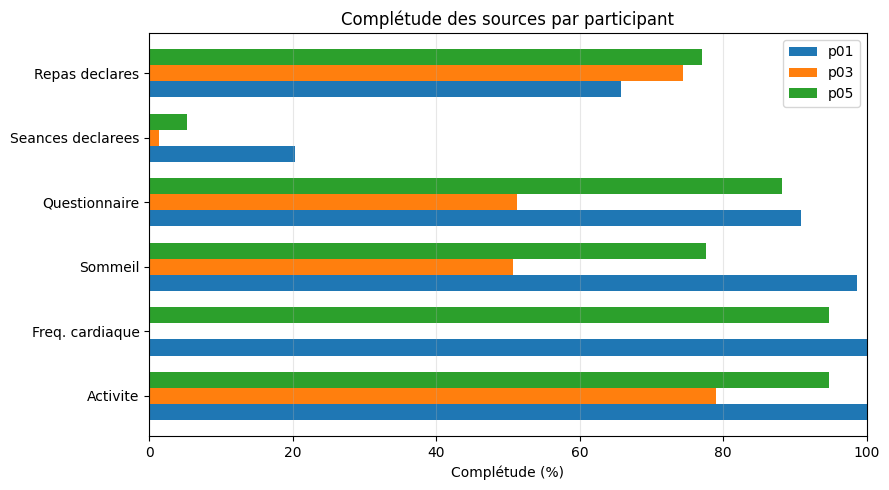

In [23]:
import matplotlib.pyplot as plt

sources = {
    "steps": "Activite",
    "hr_mean": "Freq. cardiaque",
    "sommeil_min": "Sommeil",
    "readiness": "Questionnaire",
    "srpe_total": "Seances declarees",
    "n_repas": "Repas declares",
}

comp = (df.groupby("participant")[list(sources)]
          .apply(lambda g: g.notna().mean() * 100)
          .rename(columns=sources))

ax = comp.T.plot(kind="barh", figsize=(9, 5), width=0.75)
ax.set_xlabel("Complétude (%)")
ax.set_xlim(0, 100)
ax.set_ylabel("")
ax.legend(title="")
ax.grid(axis="x", alpha=0.3)
plt.title("Complétude des sources par participant")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer

col = "sommeil_min"
observe = df[col].dropna()

# 2. mediane globale
med_glob = df[col].fillna(df[col].median())

# 3. mediane par participant
med_part = df.groupby("participant")[col].transform(lambda s: s.fillna(s.median()))

# 4. propagation de la derniere valeur, limitee
ffill = df.groupby("participant")[col].ffill(limit=2)

comparaison = pd.DataFrame({
    "observe": observe.describe(),
    "mediane_globale": med_glob.describe(),
    "mediane_participant": med_part.describe(),
    "ffill_limite_2j": ffill.describe(),
}).round(1)

print(comparaison)
print("\nNaN restants apres ffill :", ffill.isna().sum())

       observe  mediane_globale  mediane_participant  ffill_limite_2j
count    345.0            456.0                456.0            389.0
mean     374.6            372.0                376.0            376.1
std       92.3             80.4                 80.4             94.9
min       58.0             58.0                 58.0             58.0
25%      329.0            341.0                341.0            331.0
50%      364.0            364.0                371.5            364.0
75%      403.0            387.2                387.2            403.0
max      864.0            864.0                864.0            864.0

NaN restants apres ffill : 67


## 5. Construction des variables

Les valeurs brutes quotidiennes rendent mal compte de deux phénomènes établis en
sciences du sport : l'accumulation de charge sur plusieurs jours, et l'écart d'un
individu à sa propre norme. Les variables construites ci-dessous adressent ces
deux dimensions.

Toutes sont décalées d'un jour lorsqu'elles sont destinées à la prédiction : au
moment où un score serait produit, les données du jour même ne sont pas encore
disponibles.

In [25]:
df = df.sort_values(["participant", "date"]).reset_index(drop=True)
g = df.groupby("participant")

# charge aigue et chronique, a partir des pas
df["charge_7j"] = (g["steps"].shift(1)
                     .rolling(7, min_periods=4).sum()
                     .reset_index(level=0, drop=True))
df["charge_28j"] = (g["steps"].shift(1)
                      .rolling(28, min_periods=14).sum()
                      .reset_index(level=0, drop=True))
df["acwr"] = df["charge_7j"] / (df["charge_28j"] / 4)

# dette de sommeil : ecart cumule au seuil de 7h sur 14 jours
df["dette_sommeil"] = (g["sommeil_min"].shift(1)
                         .rolling(14, min_periods=7)
                         .apply(lambda s: (420 - s).clip(lower=0).sum())
                         .reset_index(level=0, drop=True))

In [26]:
print(df[["charge_7j", "charge_28j", "acwr", "dette_sommeil"]].describe().round(1))

       charge_7j  charge_28j   acwr  dette_sommeil
count      419.0       416.0  399.0          359.0
mean     69136.1    268883.2    1.0          750.9
std      26907.8     99743.9    0.3          242.1
min       6736.0     62168.0    0.3          169.0
25%      48431.0    187288.8    0.9          586.5
50%      75831.0    307564.5    1.0          738.0
75%      90615.0    356235.5    1.1          947.0
max     122026.0    403602.0    3.0         1261.0


### Charge d'entraînement

Faute de sRPE exploitable (91 % de manquants), la charge est approchée par le
volume d'activité mesuré par le bracelet. Ce proxy mesure le déplacement et non
l'intensité de l'effort, ce qui constitue une limitation à conserver en tête.

Trois indicateurs sont construits : charge aiguë (7 jours), charge chronique
(28 jours), et leur ratio (ACWR).

L'ACWR fait l'objet de critiques méthodologiques importantes. Impellizzeri et al.
(IJSPP, 2020) concluent qu'aucune preuve ne soutient son usage pour la gestion de
charge, et que les propriétés statistiques du ratio en font une métrique imprécise
introduisant bruit et artefacts. Les problèmes identifiés incluent le couplage
mathématique entre numérateur et dénominateur et le découpage artificiel de
données continues. Un travail ultérieur des mêmes auteurs (Sports Medicine, 2021)
montre que des charges chroniques tirées aléatoirement performent aussi bien que
l'ACWR réel.

L'ACWR est donc conservé à titre conventionnel, mais les charges brutes sur 7 et
28 jours sont maintenues en parallèle comme prédicteurs principaux.

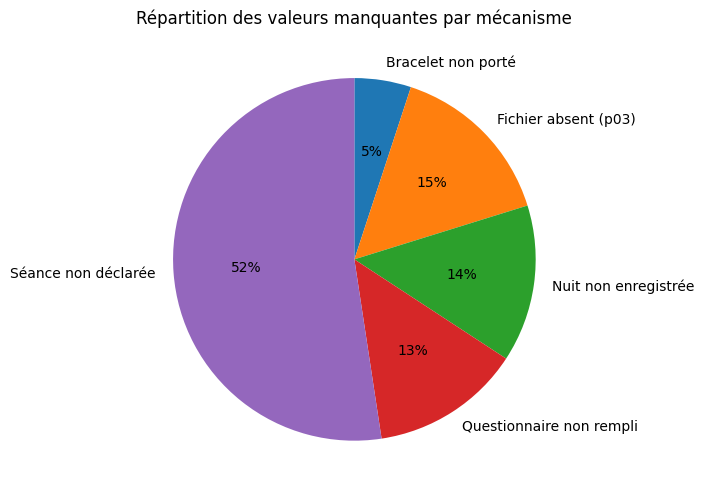

In [27]:
causes = {
    "Bracelet non porté": (df["steps"].isna()).sum(),
    "Fichier absent (p03)": (df["hr_mean"].isna() & df["steps"].notna()).sum(),
    "Nuit non enregistrée": (df["sommeil_min"].isna()).sum(),
    "Questionnaire non rempli": (df["readiness"].isna()).sum(),
    "Séance non déclarée": (df["srpe_total"].isna()).sum(),
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(causes.values(), labels=causes.keys(), autopct="%1.0f%%",
       startangle=90, counterclock=False)
ax.set_title("Répartition des valeurs manquantes par mécanisme")
plt.tight_layout()
plt.show()

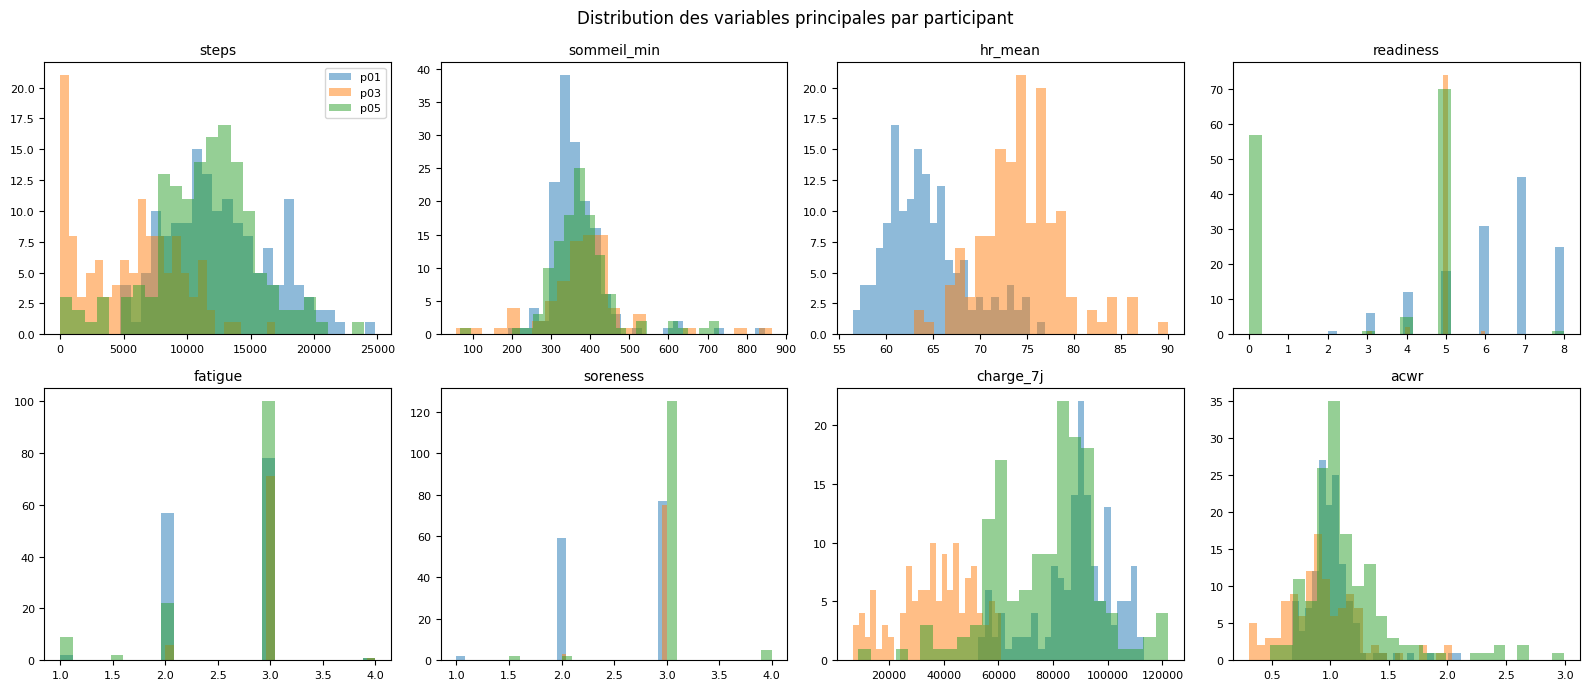

In [28]:
variables = ["steps", "sommeil_min", "hr_mean", "readiness",
             "fatigue", "soreness", "charge_7j", "acwr"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, var in zip(axes.flat, variables):
    for pid in PARTICIPANTS:
        sub = df.loc[df["participant"] == pid, var].dropna()
        if len(sub):
            ax.hist(sub, bins=25, alpha=0.5, label=pid)
    ax.set_title(var, fontsize=10)
    ax.tick_params(labelsize=8)

axes[0, 0].legend(fontsize=8)
fig.suptitle("Distribution des variables principales par participant")
plt.tight_layout()
plt.show()

In [29]:
print(df.groupby("participant")["readiness"].value_counts().unstack(fill_value=0))
w = pd.read_csv(base / "p05" / "pmsys" / "wellness.csv")
zeros = w[w["readiness"] == 0]
print(len(zeros), "lignes avec readiness = 0")
print(zeros[["fatigue", "mood", "sleep_quality", "soreness", "stress"]].describe().round(1))
w = pd.read_csv(base / "p05" / "pmsys" / "wellness.csv")
w["date"] = pd.to_datetime(w["effective_time_frame"], utc=True).dt.normalize().dt.tz_localize(None)
w["zero"] = (w["readiness"] == 0)
print(w.groupby(w["date"].dt.to_period("M"))["zero"].agg(["sum", "count"]))

readiness    0.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0
participant                                        
p01            0    1    6   12   18   31   45   25
p03            0    0    1    2   74    1    0    0
p05           57    0    1    5   70    0    0    1
60 lignes avec readiness = 0
       fatigue  mood  sleep_quality  soreness  stress
count     60.0  60.0           60.0      60.0    60.0
mean       2.3   2.2            2.4       2.9     2.1
std        0.9   0.9            0.7       0.6     0.9
min        0.0   0.0            0.0       0.0     0.0
25%        2.0   2.0            2.0       3.0     1.0
50%        3.0   2.0            2.0       3.0     2.0
75%        3.0   3.0            3.0       3.0     3.0
max        3.0   4.0            3.0       3.0     3.0
         sum  count
date               
2019-11   25     26
2019-12   31     32
2020-01    4     30
2020-02    0     22
2020-03    0     27


In [30]:
df.loc[df["readiness"] == 0, "readiness"] = np.nan
print(df.groupby("participant")["readiness"].agg(["count", "mean", "std"]).round(2))
# les cinq dimensions du questionnaire, toutes sur 1-5
positives = ["mood", "sleep_quality"]
negatives = ["fatigue", "soreness", "stress"]

# inversion des dimensions negatives : 6 - x
for col in negatives:
    df[f"{col}_inv"] = 6 - df[col]

dims = positives + [f"{c}_inv" for c in negatives]

# moyenne des cinq dimensions, ramenee sur 100
df["indice_wellness"] = df[dims].mean(axis=1) / 5 * 100

print(df.groupby("participant")["indice_wellness"].agg(["count", "mean", "std"]).round(1))

             count  mean   std
participant                   
p01            138  6.22  1.41
p03             78  4.96  0.30
p05             77  4.95  0.48
             count  mean  std
participant                  
p01            138  62.8  3.6
p03             78  60.4  1.9
p05            134  60.6  3.5


In [31]:
p01 = df[df["participant"] == "p01"]
cols = ["mood", "sleep_quality", "fatigue", "soreness", "stress", "readiness"]
print(p01[cols].corr(method="spearman")["readiness"].round(2))
dims = ["fatigue", "soreness", "sleep_quality"]
df["indice_wellness"] = df[dims].mean(axis=1) / 5 * 100

p01 = df[df["participant"] == "p01"]
print(p01[["indice_wellness", "readiness"]].corr(method="spearman").round(2))

mood             0.01
sleep_quality    0.27
fatigue          0.60
soreness         0.61
stress          -0.15
readiness        1.00
Name: readiness, dtype: float64
                 indice_wellness  readiness
indice_wellness             1.00       0.66
readiness                   0.66       1.00


In [32]:
print(df.groupby("participant")["indice_wellness"].agg(["count", "mean", "std", "min", "max"]).round(1))

             count  mean  std   min   max
participant                              
p01            138  52.2  8.0  33.3  66.7
p03             78  59.2  3.6  46.7  73.3
p05            134  55.8  7.8  26.7  80.0


In [33]:
FEATURES = [
    "steps", "calories",
    "sommeil_min", "sommeil_efficacite", "sommeil_profond",
    "charge_7j", "charge_28j", "acwr", "dette_sommeil",
    "ex_n_seances", "ex_duree_min",
    "n_repas", "glasses_of_fluid",
]

# decalage d'un jour : on predit a partir du passe
d = df.sort_values(["participant", "date"]).copy()
for f in FEATURES:
    d[f] = d.groupby("participant")[f].shift(1)

print(d[FEATURES].notna().all(axis=1).sum(), "lignes completes sur", len(d))

218 lignes completes sur 456


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

m = d.dropna(subset=["indice_wellness"]).copy()
X = m[FEATURES]
y = m["indice_wellness"]
g = m["participant"]

print(f"{len(m)} lignes, {g.nunique()} participants")

def evaluer(modele, nom):
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("m", modele),
    ])
    pred = cross_val_predict(pipe, X, y, groups=g, cv=LeaveOneGroupOut())
    print(f"{nom:20s} MAE {mean_absolute_error(y, pred):5.2f}   R2 {r2_score(y, pred):6.3f}")
    return pred

# baseline : predire la moyenne du participant
base_pred = m.groupby("participant")["indice_wellness"].transform("mean")
print(f"{'Baseline (moyenne)':20s} MAE {mean_absolute_error(y, base_pred):5.2f}   R2 {r2_score(y, base_pred):6.3f}")

p_ridge = evaluer(Ridge(alpha=1.0), "Ridge")
p_rf = evaluer(RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=0), "Random Forest")

350 lignes, 3 participants
Baseline (moyenne)   MAE  5.42   R2  0.125
Ridge                MAE  7.23   R2 -0.393
Random Forest        MAE  6.62   R2 -0.202


In [35]:
m["indice_z"] = m.groupby("participant")["indice_wellness"].transform(
    lambda s: (s - s.mean()) / s.std()
)
y_z = m["indice_z"]

for modele, nom in [(Ridge(alpha=1.0), "Ridge"),
                    (RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=0), "RF")]:
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()), ("m", modele)])
    pred = cross_val_predict(pipe, X, y_z, groups=g, cv=LeaveOneGroupOut())
    print(f"{nom:8s} MAE {mean_absolute_error(y_z, pred):5.2f}  R2 {r2_score(y_z, pred):6.3f}")

Ridge    MAE  0.80  R2 -0.071
RF       MAE  0.80  R2 -0.077


In [36]:
m["indice_veille"] = m.groupby("participant")["indice_wellness"].shift(1)
X2 = m[FEATURES + ["indice_veille"]]

pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc", StandardScaler()), ("m", Ridge(alpha=1.0))])
pred = cross_val_predict(pipe, X2, y_z, groups=g, cv=LeaveOneGroupOut())
print(f"Ridge + veille  MAE {mean_absolute_error(y_z, pred):5.2f}  R2 {r2_score(y_z, pred):6.3f}")

Ridge + veille  MAE  0.74  R2  0.043


In [37]:
b = d.dropna(subset=["blessure_etat"]).copy()
print(b.groupby("participant")["blessure_etat"].agg(["count", "sum"]))

             count   sum
participant             
p01            146   7.0
p03            104   0.0
p05             83  83.0


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

Xb = b[FEATURES]
yb = b["blessure_etat"].astype(int)
gb = b["participant"]

pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("m", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

proba = cross_val_predict(pipe, Xb, yb, groups=gb,
                          cv=LeaveOneGroupOut(), method="predict_proba")[:, 1]

print(f"ROC-AUC : {roc_auc_score(yb, proba):.3f}")
print(f"PR-AUC  : {average_precision_score(yb, proba):.3f}  (prevalence {yb.mean():.3f})")

# et par participant, ce qui est le plus parlant
b["proba"] = proba
print(b.groupby("participant")["proba"].agg(["mean", "std"]).round(3))

ROC-AUC : 0.061
PR-AUC  : 0.153  (prevalence 0.270)
              mean    std
participant              
p01          0.972  0.097
p03          0.854  0.234
p05          0.134  0.277


In [39]:
import shap

# on refait le pipeline sur le modele de readiness avec la variable veille
m_shap = m.dropna(subset=["indice_veille"]).copy()
X_shap = m_shap[FEATURES + ["indice_veille"]]
y_shap = m_shap["indice_z"]

pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("m", Ridge(alpha=1.0)),
])
pipe.fit(X_shap, y_shap)

# transformation des donnees pour SHAP
X_trans = pipe.named_steps["sc"].transform(
    pipe.named_steps["imp"].transform(X_shap)
)
X_trans = pd.DataFrame(X_trans, columns=X_shap.columns)

explainer = shap.Explainer(pipe.named_steps["m"], X_trans)
valeurs = explainer(X_trans)

importance = pd.Series(
    np.abs(valeurs.values).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

print(importance.round(3))

C:\Users\ghiattka\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


calories              0.335
steps                 0.223
charge_28j            0.188
indice_veille         0.186
glasses_of_fluid      0.108
ex_n_seances          0.101
sommeil_efficacite    0.094
ex_duree_min          0.076
dette_sommeil         0.073
acwr                  0.070
sommeil_min           0.066
sommeil_profond       0.061
charge_7j             0.053
n_repas               0.025
dtype: float64
